
# Snore Detection — Non‑Deep Models Run Book (RF / SVM / Logistic Regression)

This run book **keeps the same augmentation code** you used in your project (random SNR noise mix from ESC‑50) and the **same feature extractor (YAMNet)**, then swaps the prediction head for **Random Forest, SVM (RBF), and Logistic Regression** — compared in one place on clean and noisy tests.


In [ ]:

#@title ✅ Install dependencies
!pip install -q librosa soundfile noisereduce tensorflow_hub tqdm scikit-learn matplotlib pandas


In [ ]:

#@title 🔐 Mount Drive & set up Kaggle (upload kaggle.json when prompted)
from google.colab import drive
drive.mount('/content/drive')

!pip install -q kaggle
from google.colab import files
print("Please upload kaggle.json (Account > Create New API Token)")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Mounted at /content/drive
Please upload kaggle.json (Account > Create New API Token)


Saving kaggle.json to kaggle.json


In [ ]:

#@title ⬇️ Download datasets (Snoring + ESC‑50 as noise)
import os, sys

!mkdir -p "/content/drive/MyDrive/snore_data"
!mkdir -p "/content/drive/MyDrive/noise_data"

!kaggle datasets download tareqkhanemu/snoring -p "/content/drive/MyDrive/snore_data" --unzip
!kaggle datasets download mmoreaux/environmental-sound-classification-50 -p "/content/drive/MyDrive/noise_data" --unzip

SNORE_PATH      = "/content/drive/MyDrive/snore_data/Snoring Dataset/1"
NON_SNORE_PATH  = "/content/drive/MyDrive/snore_data/Snoring Dataset/0"
NOISE_PATH      = "/content/drive/MyDrive/noise_data/audio/audio"  # same as in your project

def count_wavs(path):
    try:
        return len([f for f in os.listdir(path) if f.lower().endswith('.wav')])
    except Exception:
        return 0

print("SNORE_PATH     :", SNORE_PATH, " | wavs:", count_wavs(SNORE_PATH))
print("NON_SNORE_PATH :", NON_SNORE_PATH, " | wavs:", count_wavs(NON_SNORE_PATH))
print("NOISE_PATH     :", NOISE_PATH, " | wavs:", count_wavs(NOISE_PATH))

assert count_wavs(SNORE_PATH) > 0, "No snore wavs found. Check SNORE_PATH."
assert count_wavs(NON_SNORE_PATH) > 0, "No non‑snore wavs found. Check NON_SNORE_PATH."
assert count_wavs(NOISE_PATH) > 0, "No noise wavs found. Check NOISE_PATH (matches your project)."


Dataset URL: https://www.kaggle.com/datasets/tareqkhanemu/snoring
License(s): unknown
snoring.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset URL: https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50
License(s): CC-BY-NC-SA-4.0
environmental-sound-classification-50.zip: Skipping, found more recently modified local copy (use --force to force download)
SNORE_PATH     : /content/drive/MyDrive/snore_data/Snoring Dataset/1  | wavs: 500
NON_SNORE_PATH : /content/drive/MyDrive/snore_data/Snoring Dataset/0  | wavs: 500
NOISE_PATH     : /content/drive/MyDrive/noise_data/audio/audio  | wavs: 2000


In [ ]:

#@title 🎛️ Load YAMNet (feature extractor, unchanged)
import tensorflow_hub as hub
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")
yamnet_model


<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject at 0x7b09b9a19fd0>

In [ ]:

#@title 🎚️ Augmentation + feature extraction (same as your project)
import numpy as np, librosa, random, tensorflow as tf, os

noise_files = [os.path.join(NOISE_PATH, f) for f in os.listdir(NOISE_PATH) if f.lower().endswith(".wav")]
assert len(noise_files) > 0, "No noise wavs found — check NOISE_PATH."

def mix_audio_with_noise(audio, noise, snr_db=10):
    if len(noise) < len(audio):
        reps = int(np.ceil(len(audio)/len(noise)))
        noise = np.tile(noise, reps)
    noise = noise[:len(audio)]
    eps = 1e-9
    rms_s = np.sqrt(np.mean(audio**2) + eps)
    rms_n = np.sqrt(np.mean(noise**2) + eps)
    k = rms_s / ((10**(snr_db/20)) * rms_n)
    return audio + k*noise

def load_with_optional_noise(file_path, add_noise=False, sr=16000, target_sec=3.0):
    y, _ = librosa.load(file_path, sr=sr, mono=True)
    target_len = int(sr*target_sec)
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]
    if add_noise and noise_files:
        n, _ = librosa.load(random.choice(noise_files), sr=sr, mono=True)
        snr = random.uniform(5, 20)  # dB
        y = mix_audio_with_noise(y, n, snr_db=snr)
    return y.astype(np.float32)

def extract_yamnet_stats_from_waveform(y):
    """
    Input: waveform y (float32, 16kHz mono, ~3s)
    Output: 2048-D features = concat(mean, std) over time of YAMNet embeddings (T,1024)
    """
    y_tf = tf.convert_to_tensor(y, dtype=tf.float32)
    _, embeddings, _ = yamnet_model(y_tf)  # embeddings: (T, 1024)
    E = embeddings.numpy()
    return np.concatenate([E.mean(axis=0), E.std(axis=0)], axis=0)  # (2048,)


In [ ]:

#@title 🧱 Build dataset (paths + labels) and split
from sklearn.model_selection import train_test_split
import os, numpy as np

snore_files = [os.path.join(SNORE_PATH, f) for f in os.listdir(SNORE_PATH) if f.lower().endswith(".wav")]
non_files   = [os.path.join(NON_SNORE_PATH, f) for f in os.listdir(NON_SNORE_PATH) if f.lower().endswith(".wav")]

X_paths = snore_files + non_files
y_all   = np.array([1]*len(snore_files) + [0]*len(non_files))

X_tr_paths, X_te_paths, y_tr, y_te = train_test_split(
    X_paths, y_all, test_size=0.2, random_state=42, stratify=y_all
)

len(snore_files), len(non_files), len(X_tr_paths), len(X_te_paths)


(500, 500, 800, 200)

In [ ]:

#@title 🧬 Extract features (train with augmentation ON; test clean)
from tqdm import tqdm
import numpy as np

def features_from_paths(paths, add_noise=False):
    feats = []
    for p in tqdm(paths, desc=f"Extracting (add_noise={add_noise})"):
        y = load_with_optional_noise(p, add_noise=add_noise, sr=16000, target_sec=3.0)
        feats.append(extract_yamnet_stats_from_waveform(y))
    return np.stack(feats)

X_tr = features_from_paths(X_tr_paths, add_noise=True)   # augment for robustness
X_te = features_from_paths(X_te_paths, add_noise=False)  # clean test
X_tr.shape, X_te.shape


Extracting (add_noise=False): 100%|██████████| 200/200 [00:43<00:00,  4.61it/s]


((800, 2048), (200, 2048))

In [ ]:

#@title 🏋️ Train models: RandomForest, SVM (RBF), LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler().fit(X_tr)
X_tr_s = scaler.transform(X_tr)
X_te_s = scaler.transform(X_te)

rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
svm = SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, random_state=42)
logreg = LogisticRegression(solver='saga', penalty='l2', C=1.0, max_iter=2000, n_jobs=-1, random_state=42)

rf.fit(X_tr, y_tr)
svm.fit(X_tr_s, y_tr)
logreg.fit(X_tr_s, y_tr)

print("✅ Models trained.")


✅ Models trained.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:

#@title 📈 Evaluation helpers (reports, ROC‑AUC, plots)
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve, auc
import numpy as np
import pandas as pd

def evaluate_model(name, clf, X, y, scaled=False):
    X_eval = scaler.transform(X) if scaled else X
    if hasattr(clf, "predict_proba"):
        probs = clf.predict_proba(X_eval)[:,1]
    elif hasattr(clf, "decision_function"):
        df = clf.decision_function(X_eval)
        df_min, df_max = df.min(), df.max()
        probs = (df - df_min) / (df_max - df_min + 1e-9)
    else:
        probs = clf.predict(X_eval)

    preds = (probs >= 0.5).astype(int)
    report = classification_report(y, preds, digits=4, output_dict=True)
    cm = confusion_matrix(y, preds)
    roc = roc_auc_score(y, probs)
    return {"name": name, "report": report, "confusion": cm, "probs": probs, "preds": preds, "roc_auc": roc}

def plot_confusion_matrix(cm, title, classes=('Non‑Snore','Snore')):
    fig = plt.figure(figsize=(4.5,4))
    ax = fig.add_subplot(111)
    ax.imshow(cm, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_xticklabels(classes, rotation=45)
    ax.set_yticks([0,1]); ax.set_yticklabels(classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]}", ha="center", va="center")
    ax.set_ylabel('True'); ax.set_xlabel('Pred')
    fig.tight_layout()
    plt.show()

def plot_roc(models_results, y_true, title="ROC (Clean Test)"):
    plt.figure(figsize=(6,5))
    for res in models_results:
        fpr, tpr, _ = roc_curve(y_true, res["probs"])
        auc_v = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{res["name"]} (AUC={auc_v:.3f})')
    plt.plot([0,1],[0,1],'--')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(title)
    plt.legend(loc='lower right')
    plt.show()

def summarize_table(clean_res, noisy_res):
    rows = []
    for r in clean_res:
        rows.append({"Model": r["name"], "Split": "Clean", "Accuracy": r["report"]["accuracy"], "F1 (Snore)": r["report"]["1"]["f1-score"], "ROC-AUC": r["roc_auc"]})
    for r in noisy_res:
        rows.append({"Model": r["name"], "Split": "Noisy", "Accuracy": r["report"]["accuracy"], "F1 (Snore)": r["report"]["1"]["f1-score"], "ROC-AUC": r["roc_auc"]})
    df = pd.DataFrame(rows).sort_values(["Split","ROC-AUC"], ascending=[True, False]).reset_index(drop=True)
    return df


=== RandomForest (CLEAN) ===
Accuracy: 0.965
F1 (Snore): 0.9655172413793104
ROC-AUC: 0.99705

=== SVM (RBF) (CLEAN) ===
Accuracy: 0.93
F1 (Snore): 0.9326923076923077
ROC-AUC: 0.9941

=== LogisticRegression (CLEAN) ===
Accuracy: 0.985
F1 (Snore): 0.9852216748768473
ROC-AUC: 0.9991



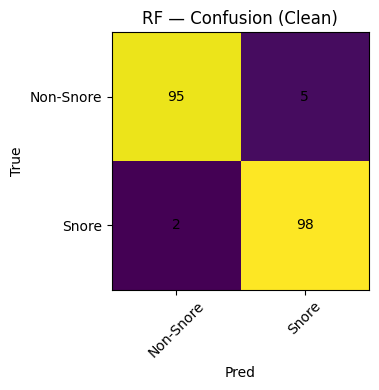

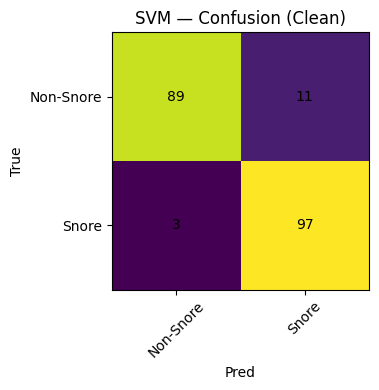

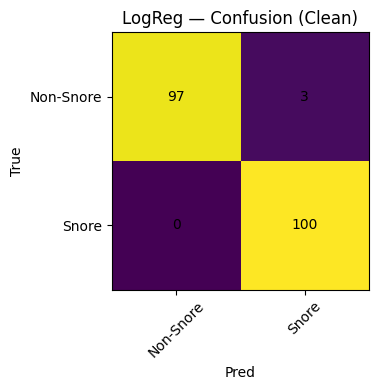

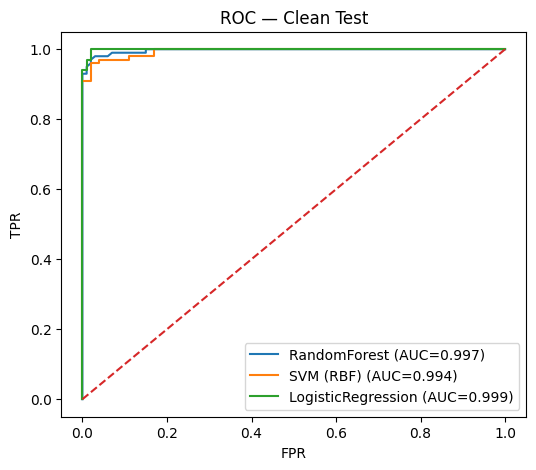

In [ ]:

#@title 🔎 Evaluate on CLEAN test set
rf_clean  = evaluate_model("RandomForest", rf, X_te, y_te, scaled=False)
svm_clean = evaluate_model("SVM (RBF)", svm, X_te, y_te, scaled=True)
lr_clean  = evaluate_model("LogisticRegression", logreg, X_te, y_te, scaled=True)

clean_results = [rf_clean, svm_clean, lr_clean]
for r in clean_results:
    print(f'=== {r["name"]} (CLEAN) ===')
    print("Accuracy:", r["report"]["accuracy"])
    print("F1 (Snore):", r["report"]["1"]["f1-score"])
    print("ROC-AUC:", r["roc_auc"])
    print()

plot_confusion_matrix(rf_clean["confusion"], "RF — Confusion (Clean)")
plot_confusion_matrix(svm_clean["confusion"], "SVM — Confusion (Clean)")
plot_confusion_matrix(lr_clean["confusion"], "LogReg — Confusion (Clean)")

plot_roc(clean_results, y_te, title="ROC — Clean Test")


=== RandomForest (NOISY) ===
Accuracy: 0.895
F1 (Snore): 0.8944723618090452
ROC-AUC: 0.9603

=== SVM (RBF) (NOISY) ===
Accuracy: 0.86
F1 (Snore): 0.86
ROC-AUC: 0.9569999999999999

=== LogisticRegression (NOISY) ===
Accuracy: 0.87
F1 (Snore): 0.8673469387755102
ROC-AUC: 0.9537



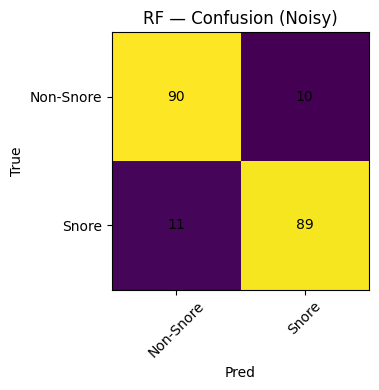

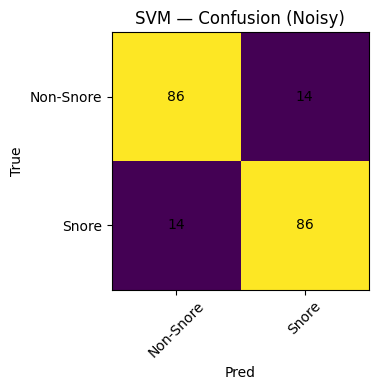

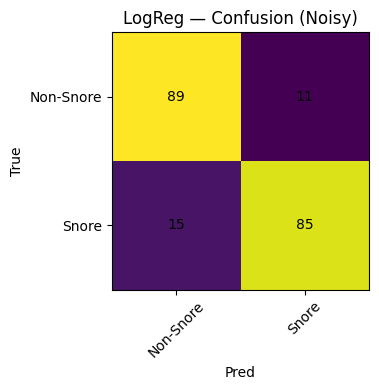

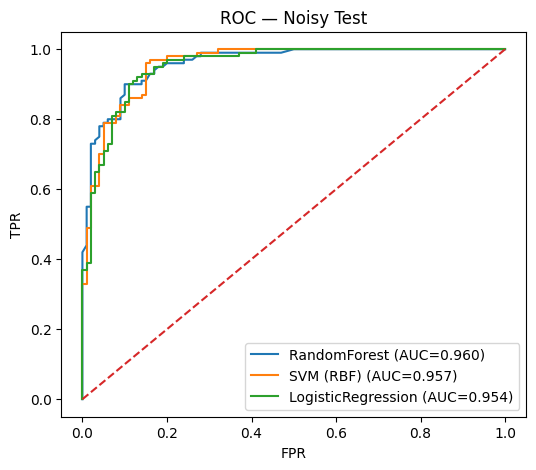

In [ ]:

#@title 🌪️ Evaluate on NOISY test set (augmented at inference)
import numpy as np
X_te_noisy = []
for p in X_te_paths:
    y = load_with_optional_noise(p, add_noise=True, sr=16000, target_sec=3.0)
    X_te_noisy.append(extract_yamnet_stats_from_waveform(y))
X_te_noisy = np.stack(X_te_noisy)

rf_noisy  = evaluate_model("RandomForest", rf, X_te_noisy, y_te, scaled=False)
svm_noisy = evaluate_model("SVM (RBF)", svm, X_te_noisy, y_te, scaled=True)
lr_noisy  = evaluate_model("LogisticRegression", logreg, X_te_noisy, y_te, scaled=True)

noisy_results = [rf_noisy, svm_noisy, lr_noisy]
for r in noisy_results:
    print(f'=== {r["name"]} (NOISY) ===')
    print("Accuracy:", r["report"]["accuracy"])
    print("F1 (Snore):", r["report"]["1"]["f1-score"])
    print("ROC-AUC:", r["roc_auc"])
    print()

plot_confusion_matrix(rf_noisy["confusion"], "RF — Confusion (Noisy)")
plot_confusion_matrix(svm_noisy["confusion"], "SVM — Confusion (Noisy)")
plot_confusion_matrix(lr_noisy["confusion"], "LogReg — Confusion (Noisy)")

plot_roc(noisy_results, y_te, title="ROC — Noisy Test")


In [ ]:

#@title 🧾 Side‑by‑side comparison
df_summary = summarize_table(clean_results, noisy_results)
df_summary


,Model,Split,Accuracy,F1 (Snore),ROC-AUC
0,LogisticRegression,Clean,0.985,0.985222,0.99910
1,RandomForest,Clean,0.965,0.965517,0.99705
2,SVM (RBF),Clean,0.930,0.932692,0.99410
3,RandomForest,Noisy,0.895,0.894472,0.96030
4,SVM (RBF),Noisy,0.860,0.860000,0.95700
5,LogisticRegression,Noisy,0.870,0.867347,0.95370



## Notes & tips
- Augmentation (random SNR ESC‑50 mix) and YAMNet features are the same as your project file.
- Tune with `GridSearchCV` / `RandomizedSearchCV`.
- Consider `class_weight="balanced"` and threshold tuning for better recall/precision trade‑offs.
